In [1]:
%load_ext autoreload
%autoreload 2
import os
import functools
from pathlib import Path
import numpy as np
from scipy.signal import argrelextrema

imginfo = lambda img: print(type(img), img.dtype, img.shape, img.min(), img.max())


os.environ["CUDA_VISIBLE_DEVICES"]="0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
return_depth = False

#dataset_location = "/tmp/clevr-act-6-var-cam2"
dataset_location = "./data/clevr-real-block-v3"
#dataset_location = "./data/trajectory"
#dataset_location = "/data/lmbraid19/argusm/datasets/clevr-real-1of5c-v1"
dataset_location = Path(dataset_location)

#model_location = Path("/mnt/lmb/lmbraid19/argusm/models/")
model_location = Path("./data/models/")
#model_path = model_location / "clevr-act-7-depth_l40" / "checkpoint-4687"
#model_path = model_location / "clevr-act-6-var-cam2_hf_af_lr3e5" / "checkpoint-4687"
#model_path = model_location / "clevr-act-7-depth_rbg20" / "checkpoint-4687"
model_path = model_location / "clevr-act-7-depth_text_aug" / "checkpoint-4687"

save_folder = "./data/prediction/"
Path(save_folder).mkdir(parents=True, exist_ok=True)

#model_path = model_location / "clevr-act-7-depth_depth_l40" / "checkpoint-4687"
if "depth_depth_l40" in str(model_path):
    return_depth = True

print("dataset_location", dataset_location)
if model_path.is_dir():
    print("moadel_path is", model_path)

dataset_location data/clevr-real-block-v3
moadel_path is data/models/clevr-act-7-depth_text_aug/checkpoint-4687


In [2]:
from data_loader_jsonl import JSONLDataset, ValidDataset
from data_augmentations import CropStart, CropMiddle, CropCenter


test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    #augment_crop=CropStart(crop_size=1000, valid=False),
    #augment_crop=CropMiddle(crop_size=500, object_size=20, valid=True),
    augment_crop=CropCenter(crop_size=500, valid=False),
    return_depth=return_depth
)

print("dataset len", len(test_dataset))

dataset len 160


160


  0%|          | 0/3 [00:00<?, ?it/s]


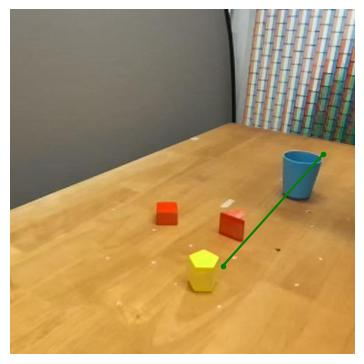
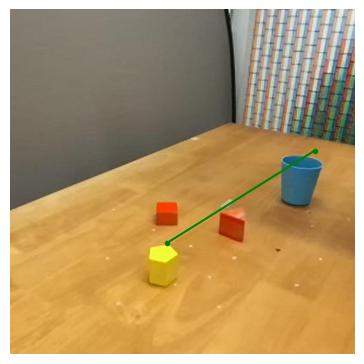
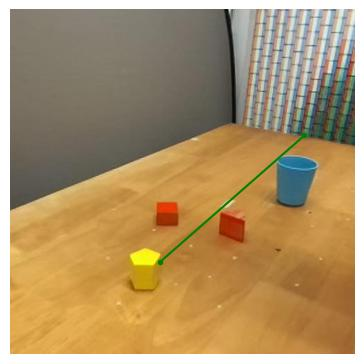

In [3]:
from IPython.display import display, HTML
from tqdm.notebook import tqdm
from utils_vis import render_example

def get_image(images):
    if isinstance(images, (list, tuple)):
        return images[-1]
    else:
        return images
    
def get_depth(images):
    if isinstance(images, (list, tuple)):
        return images[0]
    else:
        return None
    
print(len(test_dataset))
num_samples = 3
html_imgs = ""
for i in tqdm(range(23, 26)):
    images, sample = test_dataset[i]
    image = get_depth(images) if return_depth else get_image(images)
    html_imgs += render_example(image, label=sample["suffix"], text=sample["prefix"], camera=sample["camera"])
    
display(HTML(html_imgs))

In [4]:
import torch
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration

DEVICE = 'cuda' # torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.bfloat16
print('Using device:', DEVICE)


MODEL_ID ="google/paligemma2-3b-pt-224"
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)
print("loaded processor.")
model = PaliGemmaForConditionalGeneration.from_pretrained(model_path, torch_dtype=TORCH_DTYPE, device_map="auto")

def collate_fn(batch):
    images, labels = zip(*batch)
    prefixes = ["<image>" + label["prefix"] for label in labels]
    inputs = processor(
        text=prefixes,
        images=images,
        return_tensors="pt",
        padding="longest"
    ).to(TORCH_DTYPE).to(DEVICE)
    return inputs

Using device: cuda
loaded processor.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/160 [00:00<?, ?it/s]

/home/argusm/miniconda3/envs/cvla/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


/home/argusm/miniconda3/envs/cvla/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


/home/argusm/miniconda3/envs/cvla/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


/home/argusm/miniconda3/envs/cvla/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


...

/home/argusm/miniconda3/envs/cvla/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


/home/argusm/miniconda3/envs/cvla/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


/home/argusm/miniconda3/envs/cvla/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


/home/argusm/miniconda3/envs/cvla/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


/home/argusm/miniconda3/envs/cvla/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:676: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(



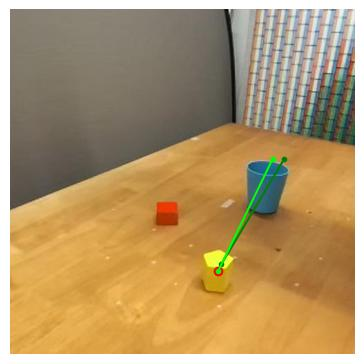
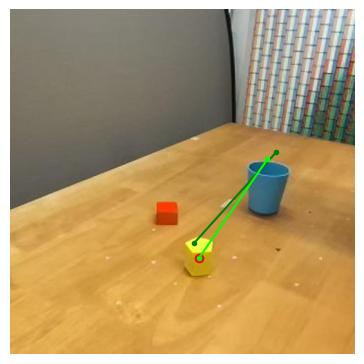
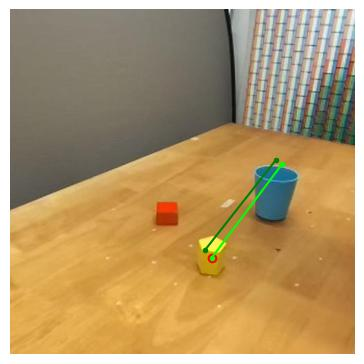
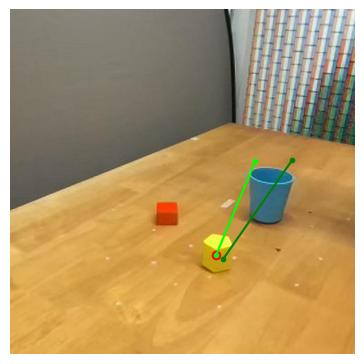
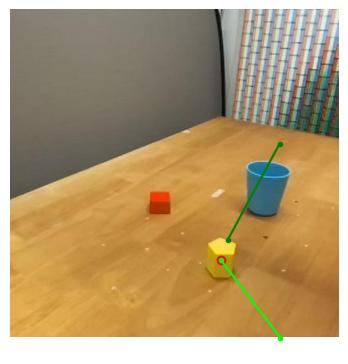
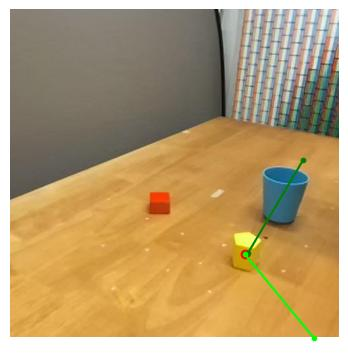
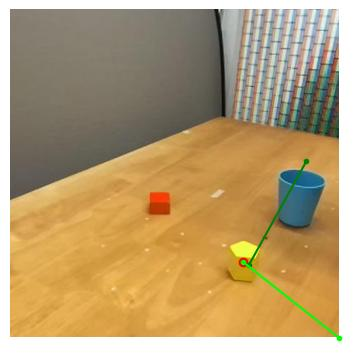
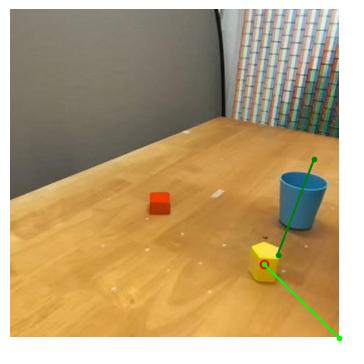
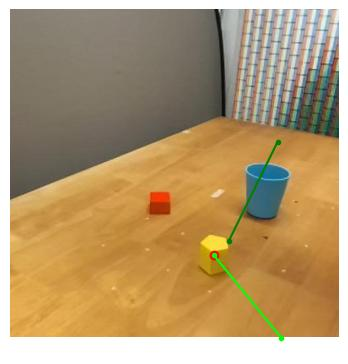
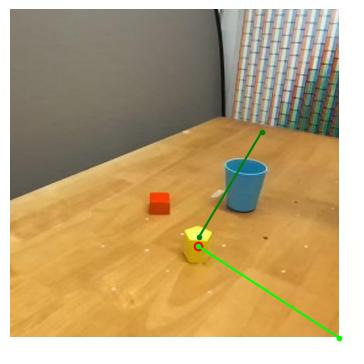
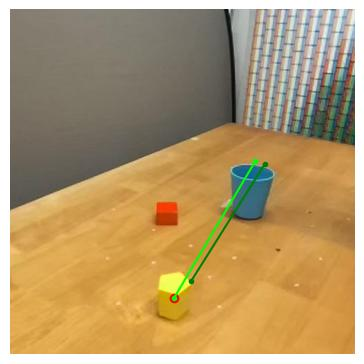
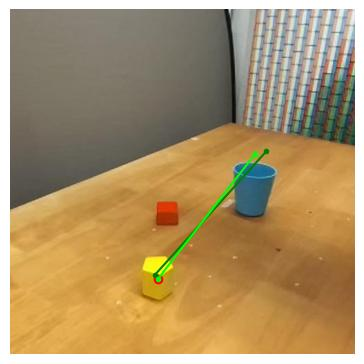
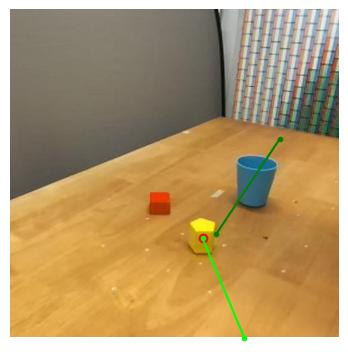
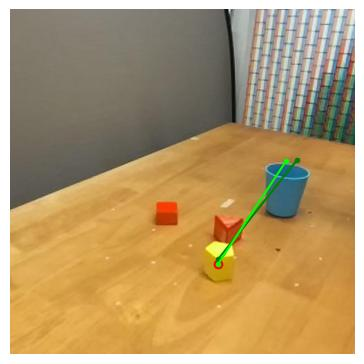
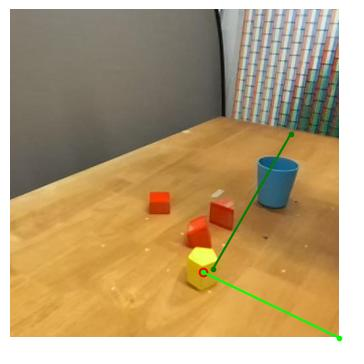
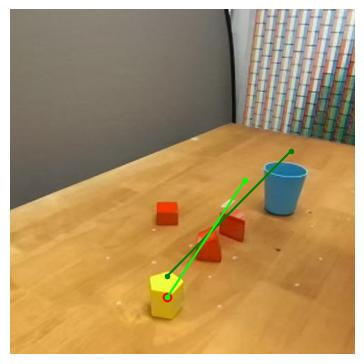
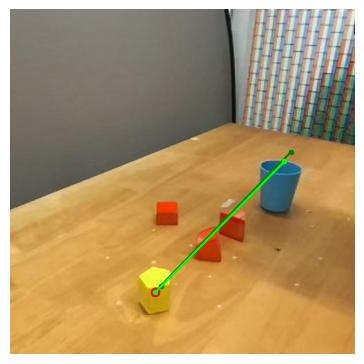
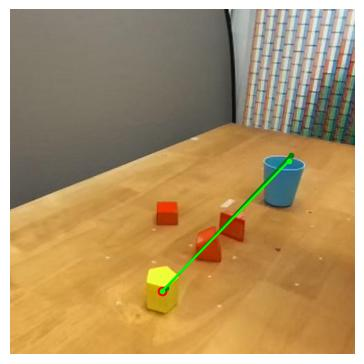
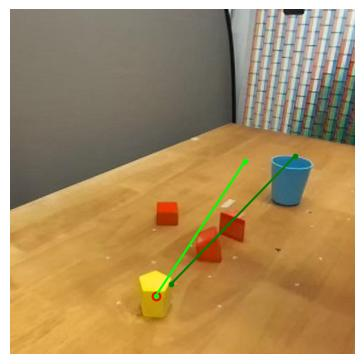
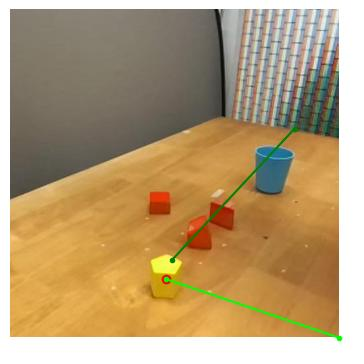
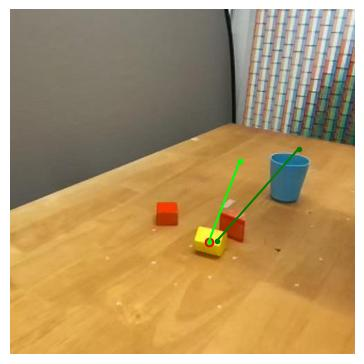
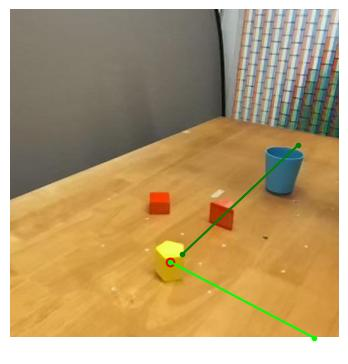
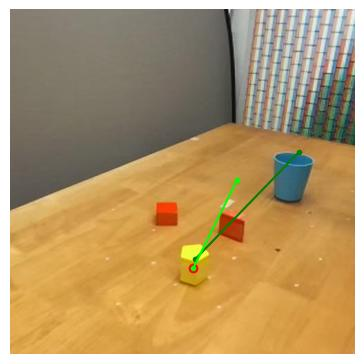
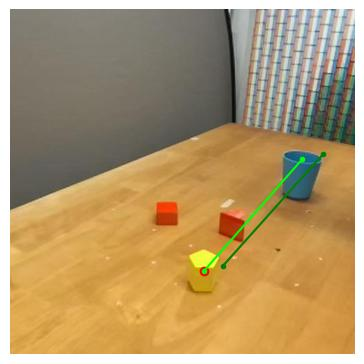
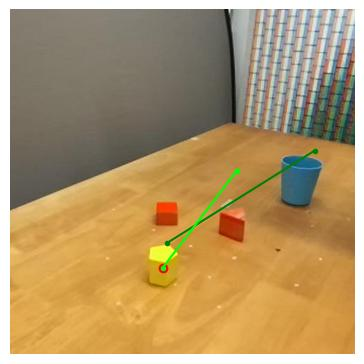
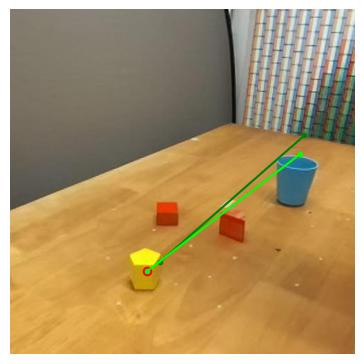
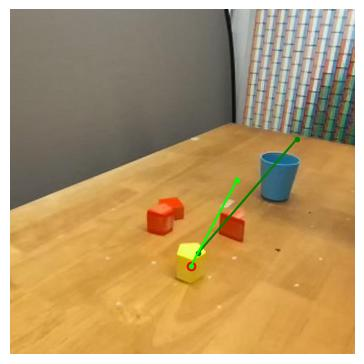
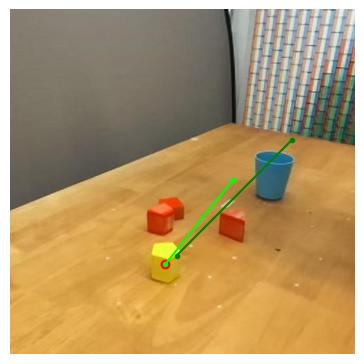
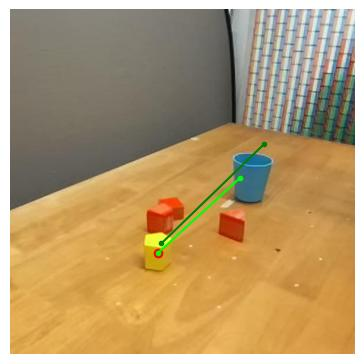
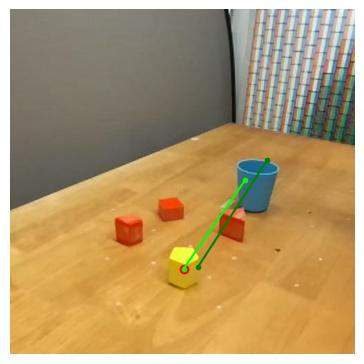
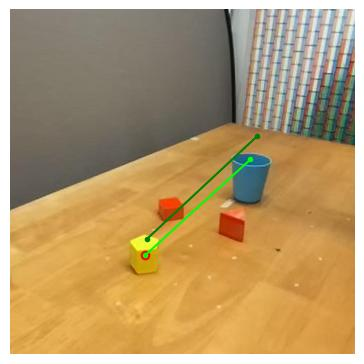
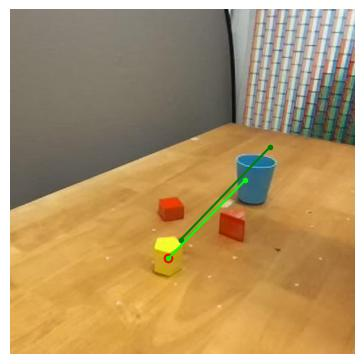
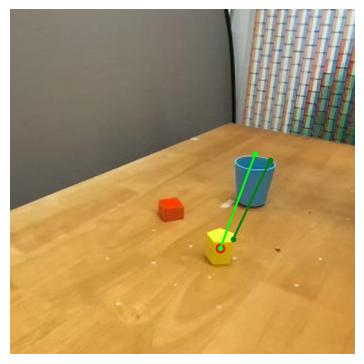
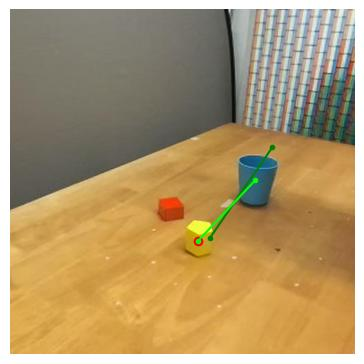
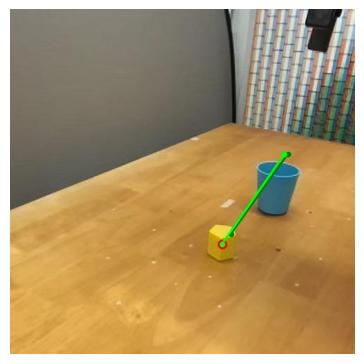
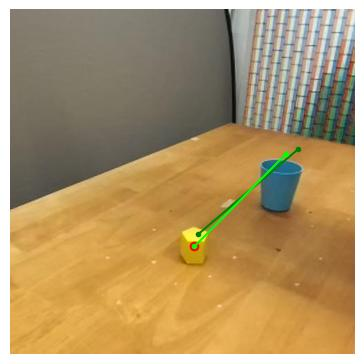
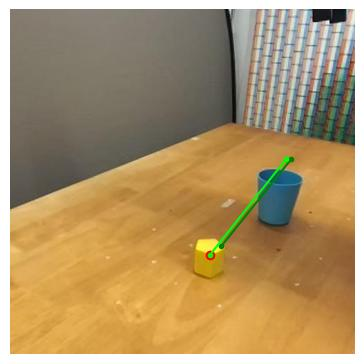
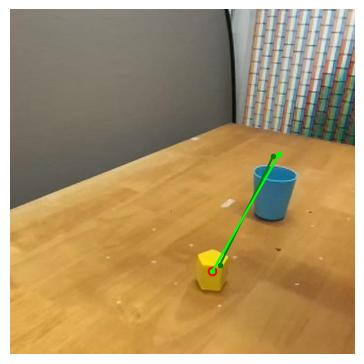
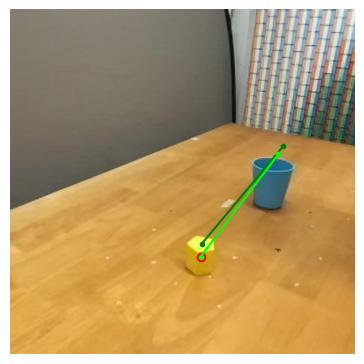
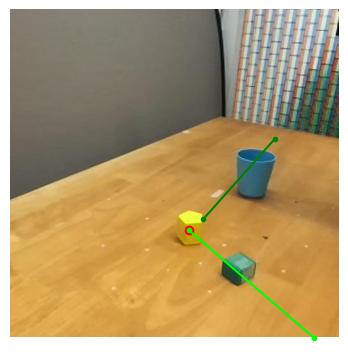
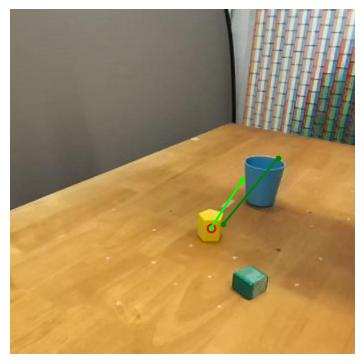
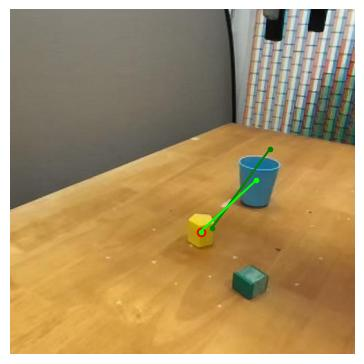
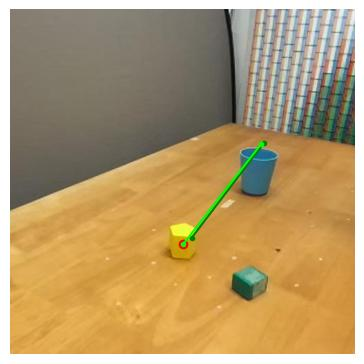
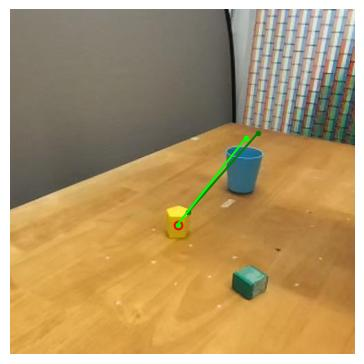
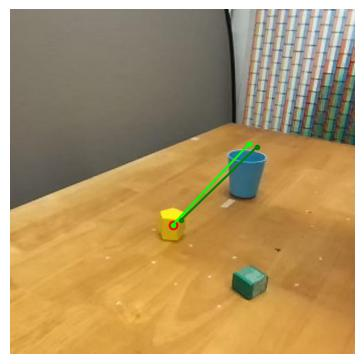
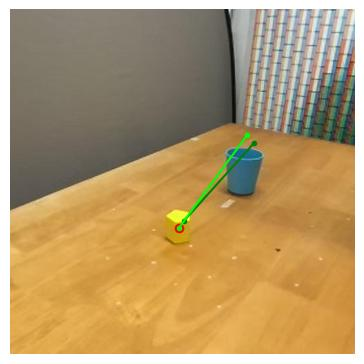
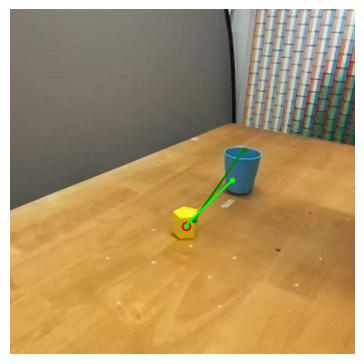
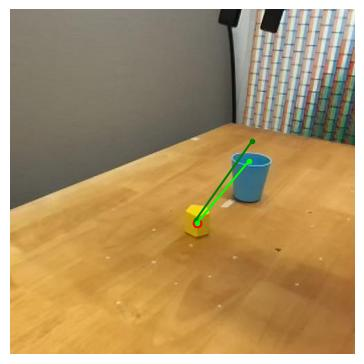
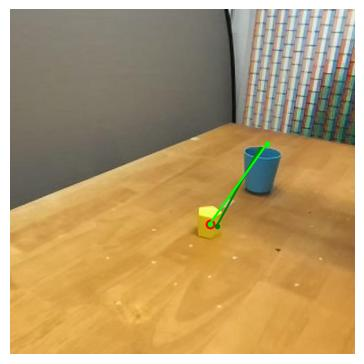
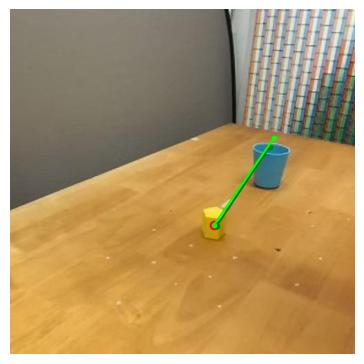
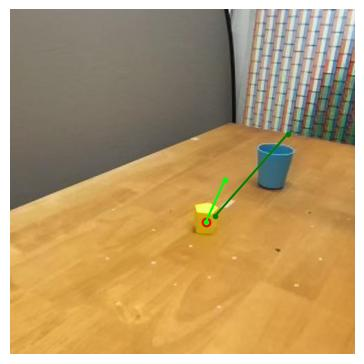
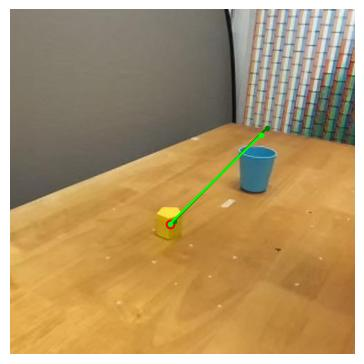
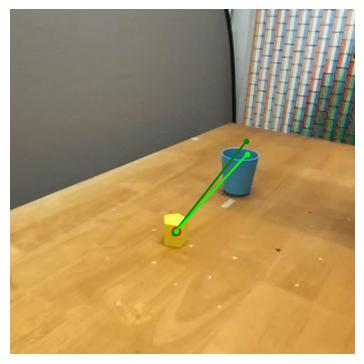
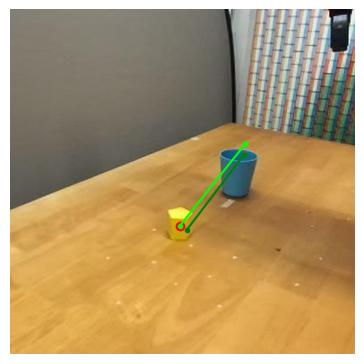
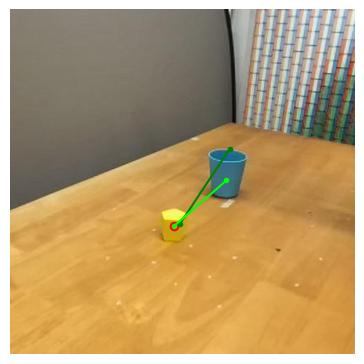
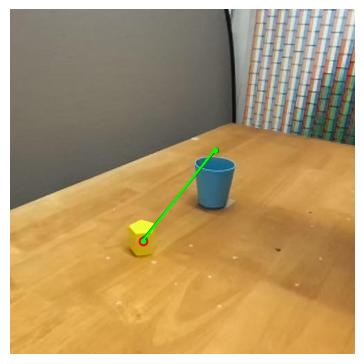
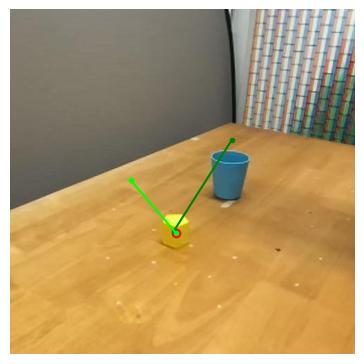
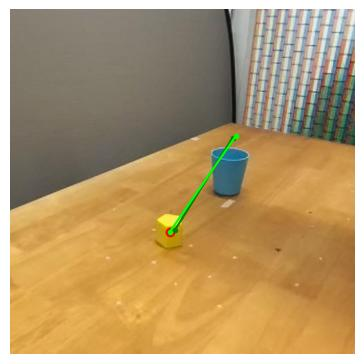
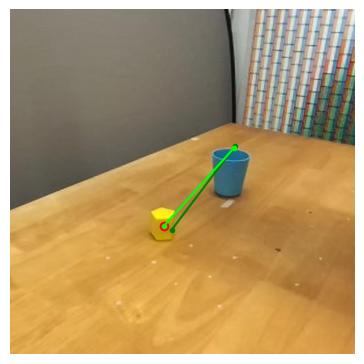
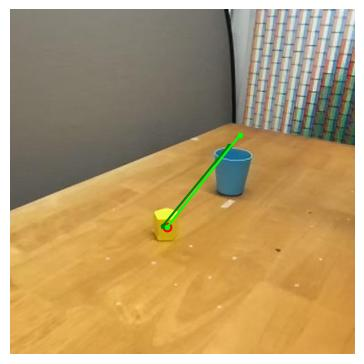
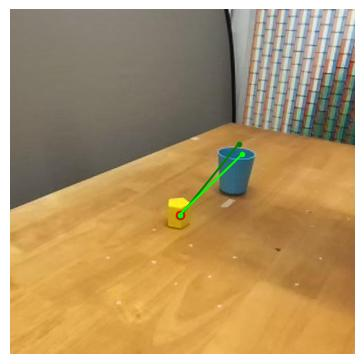
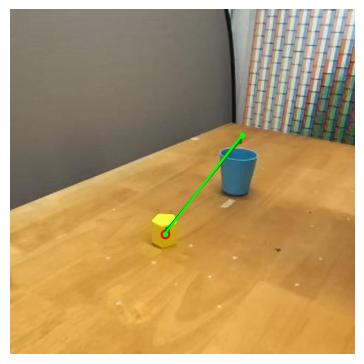
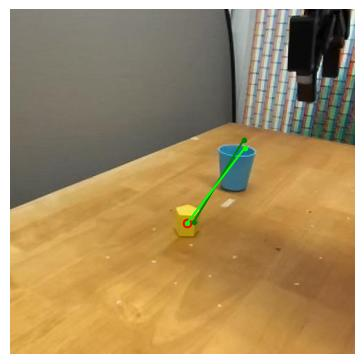
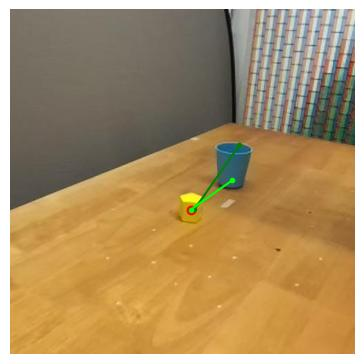
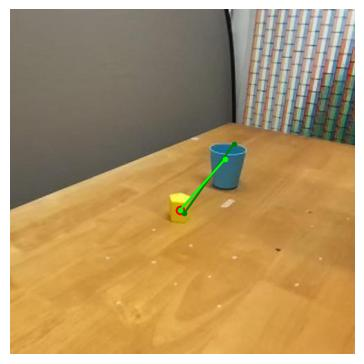
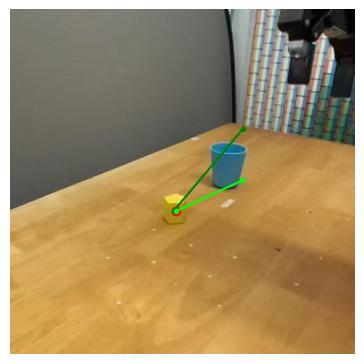
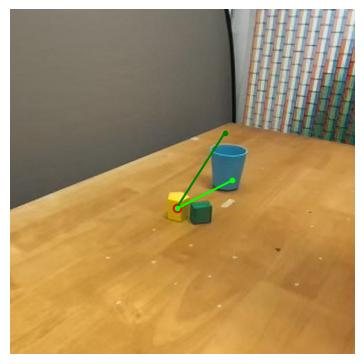
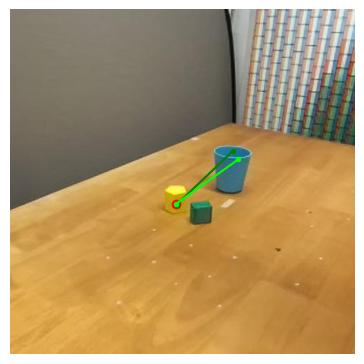
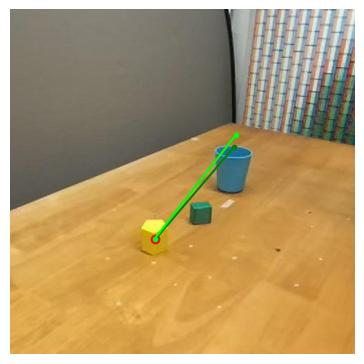
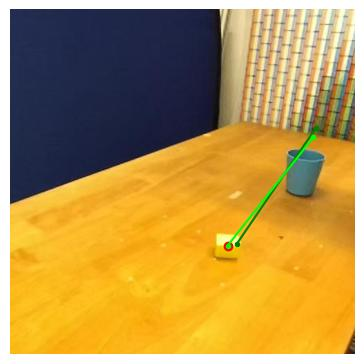
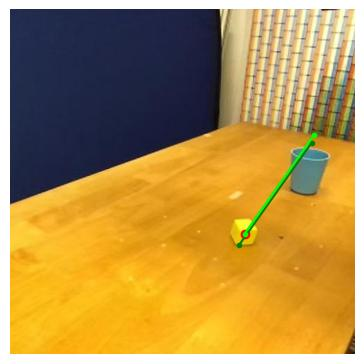
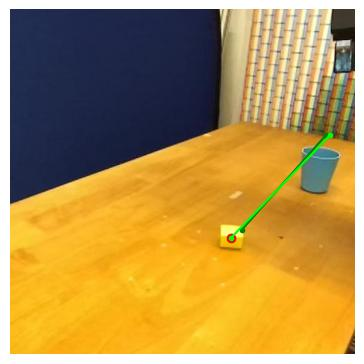
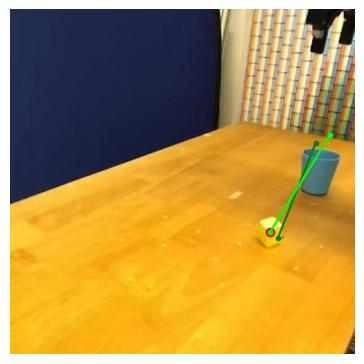
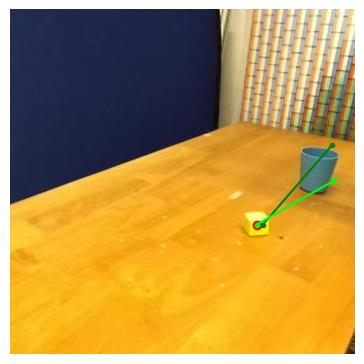
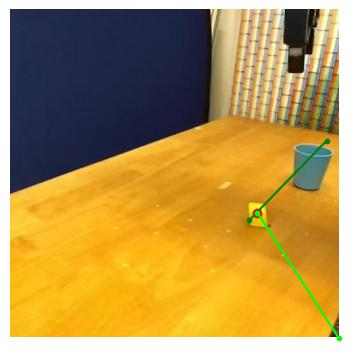
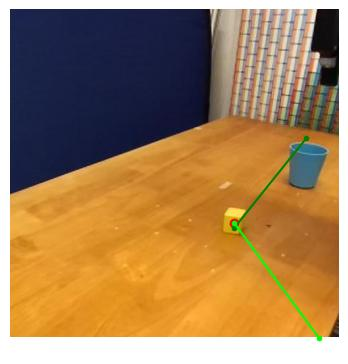
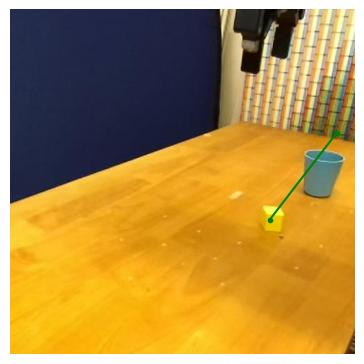
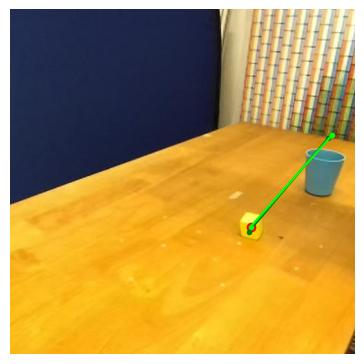
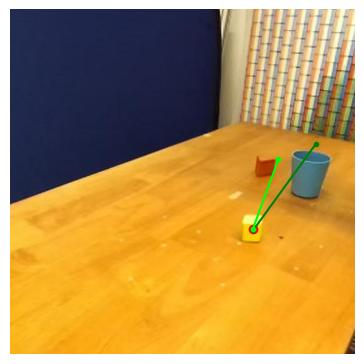
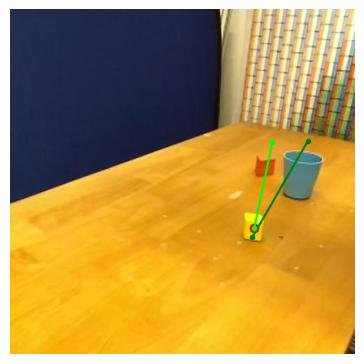
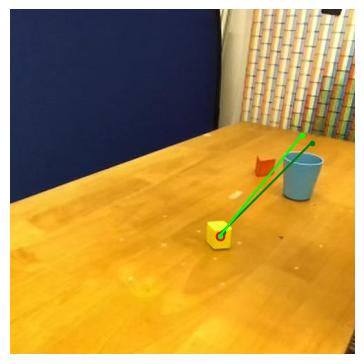
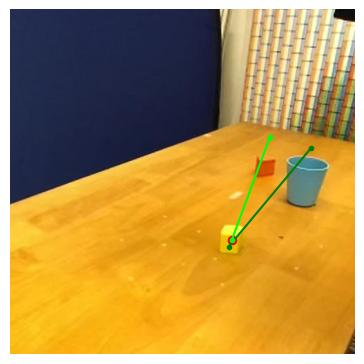
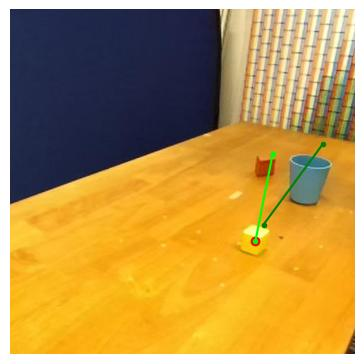
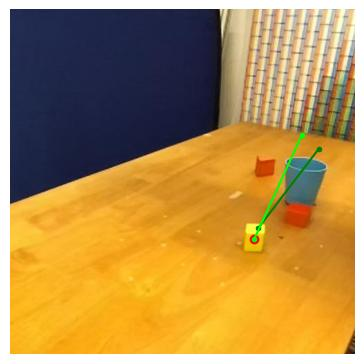
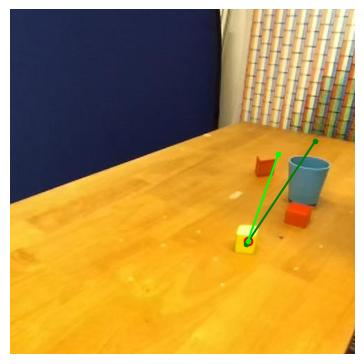
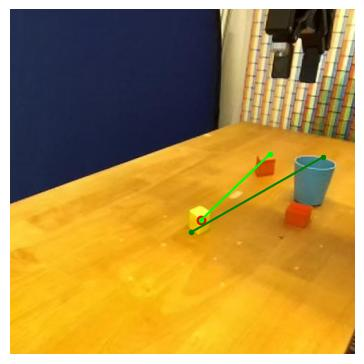
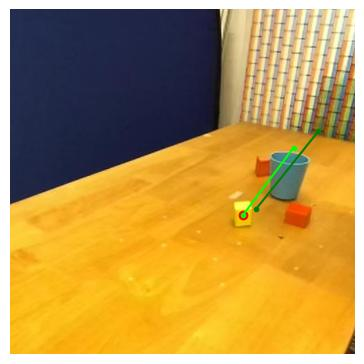
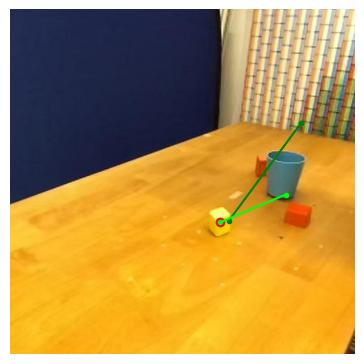
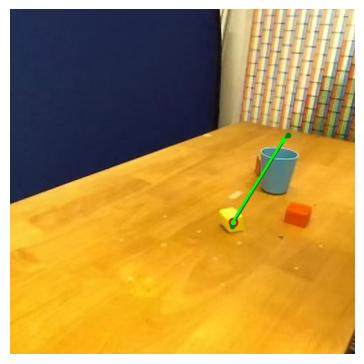
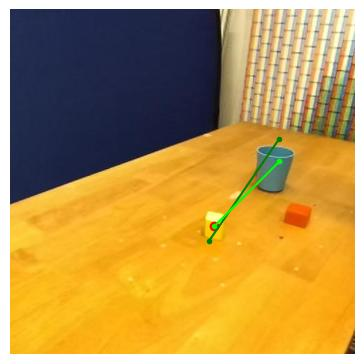
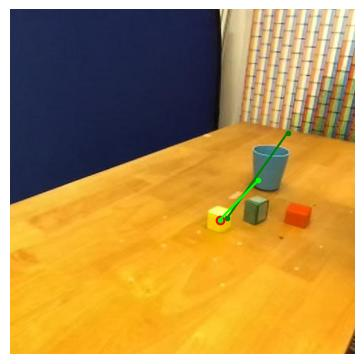
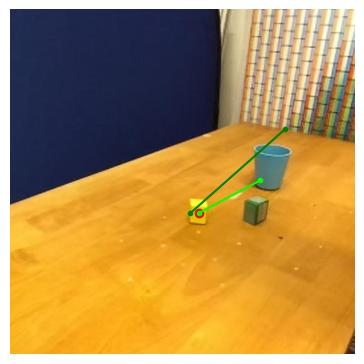
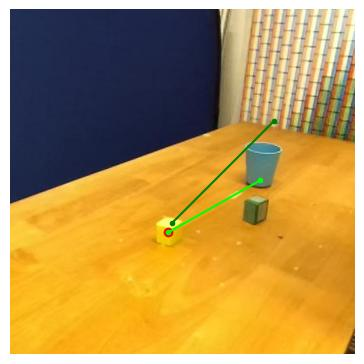
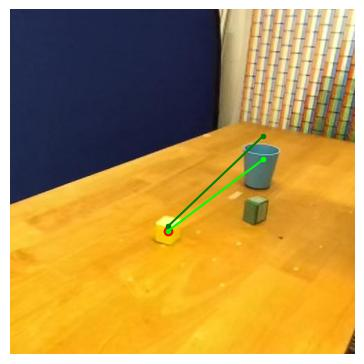
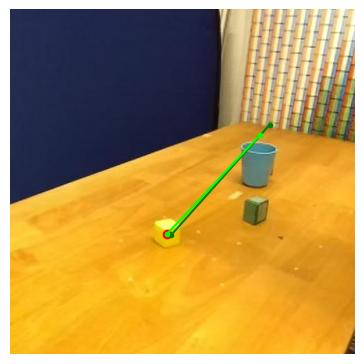
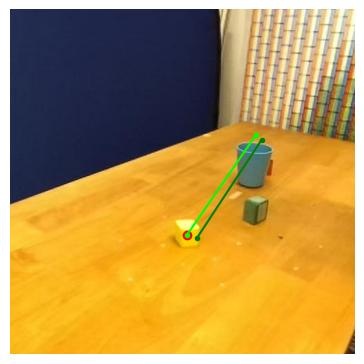
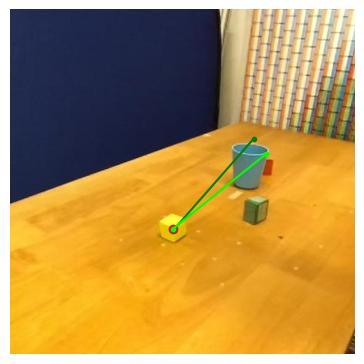
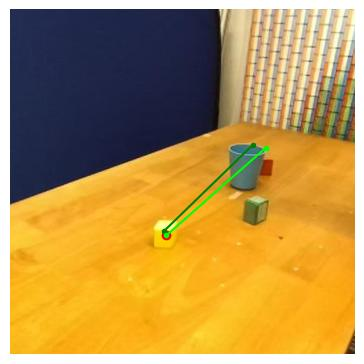
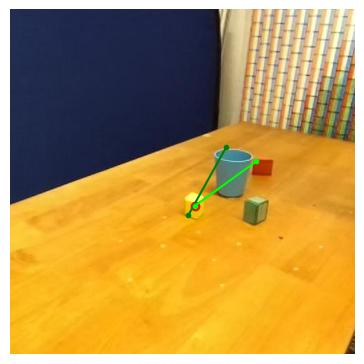
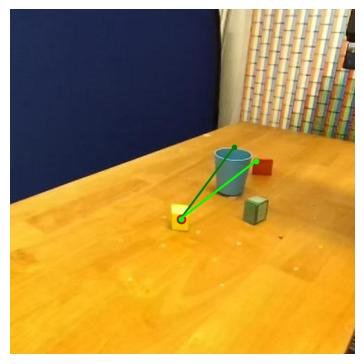
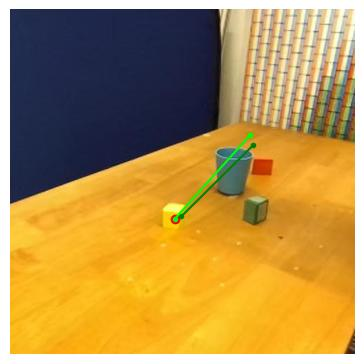
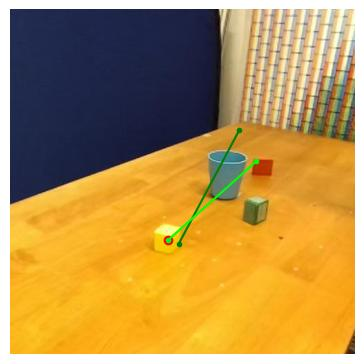
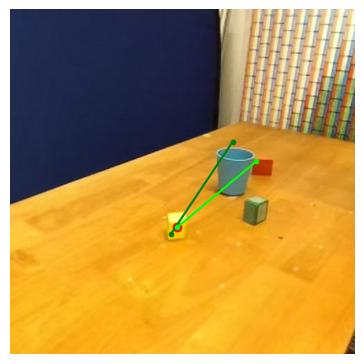
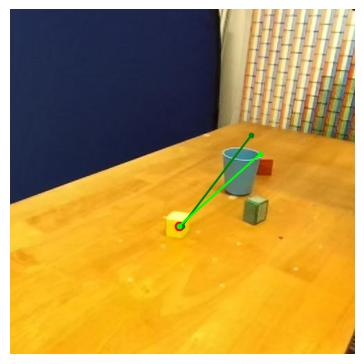
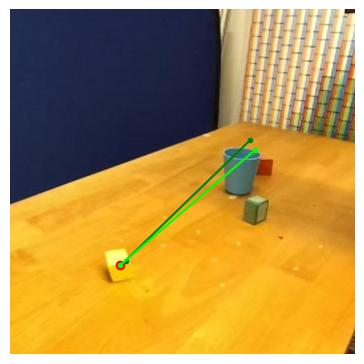
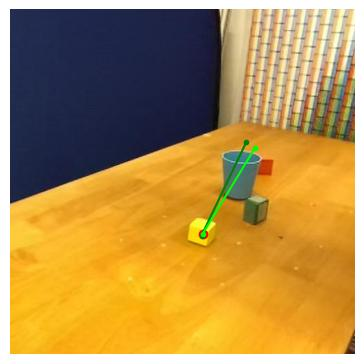
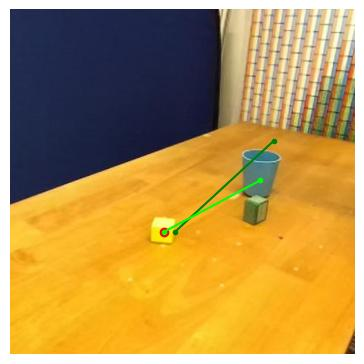
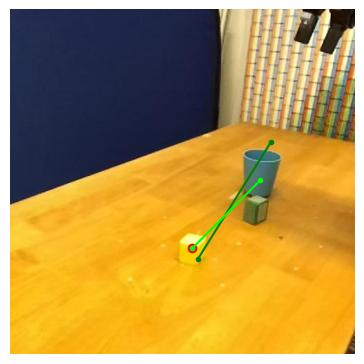
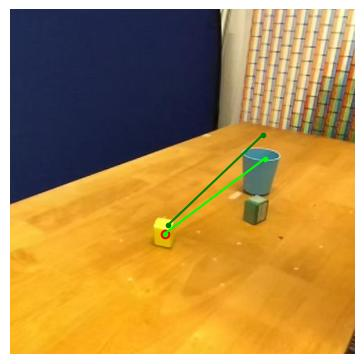
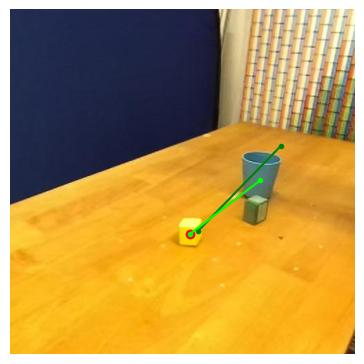
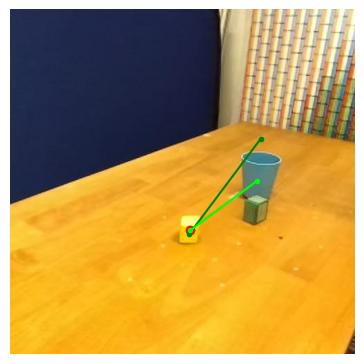
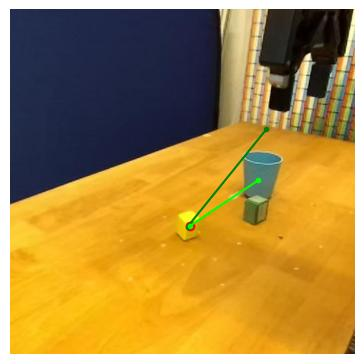
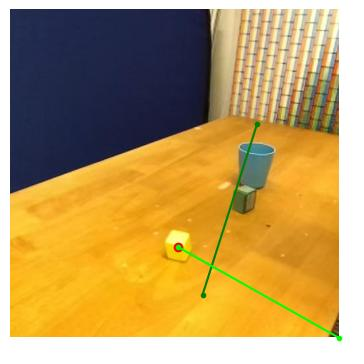
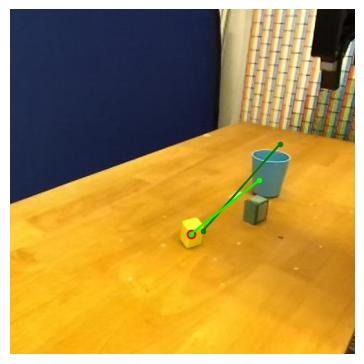
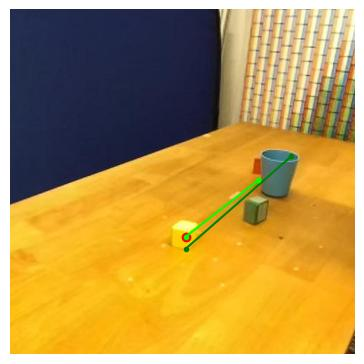
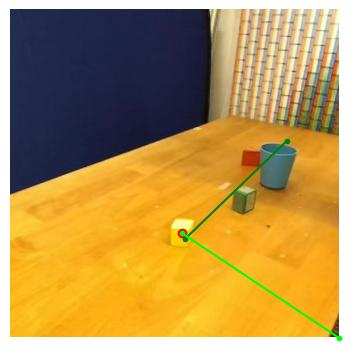
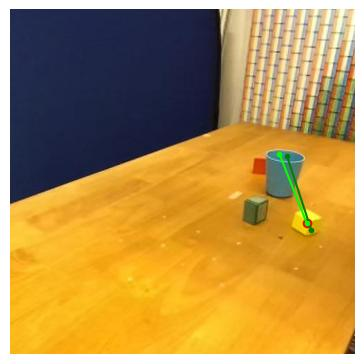
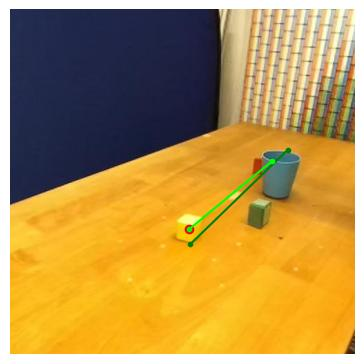
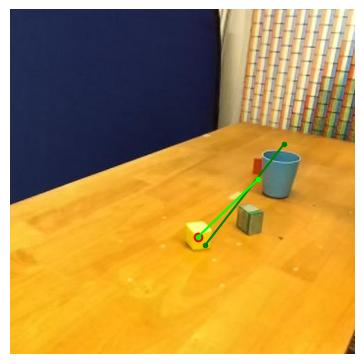
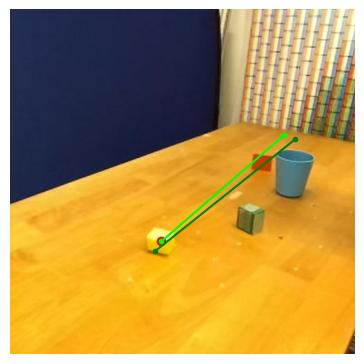
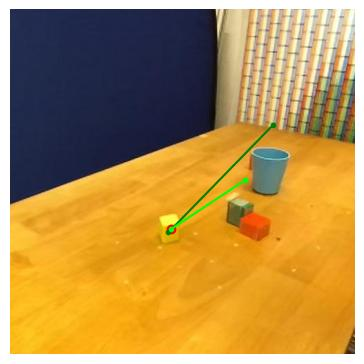
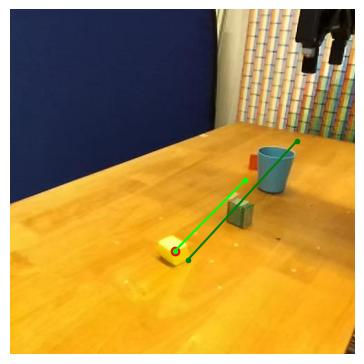
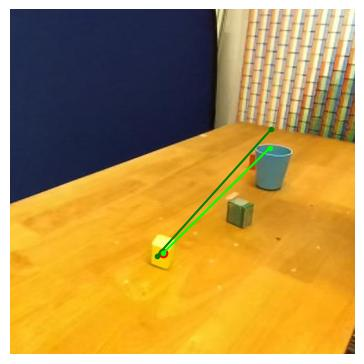
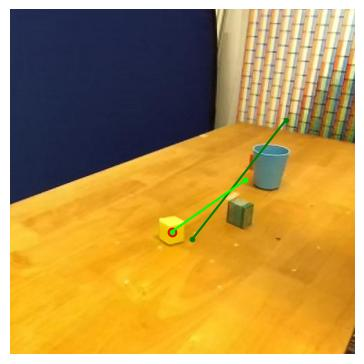
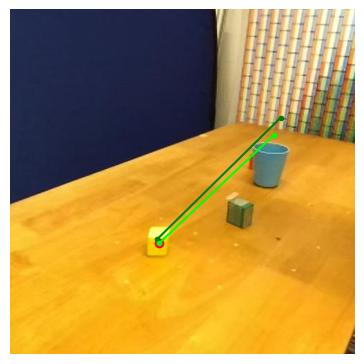
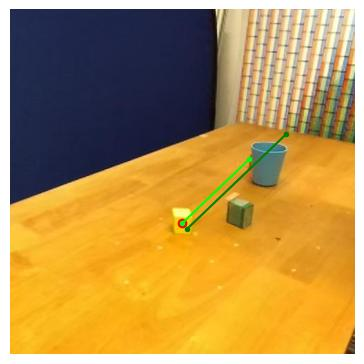
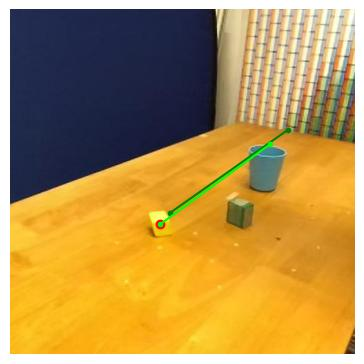
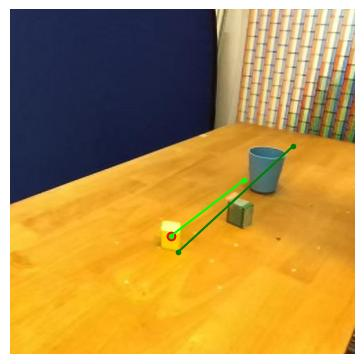
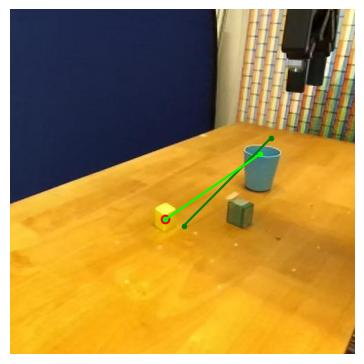
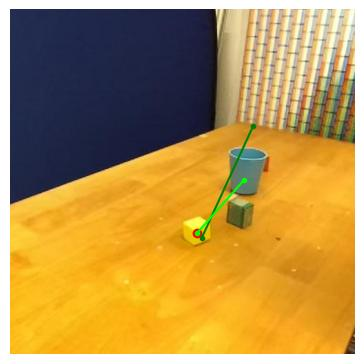
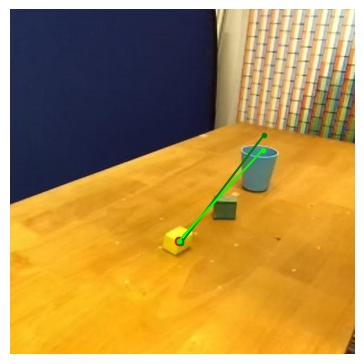
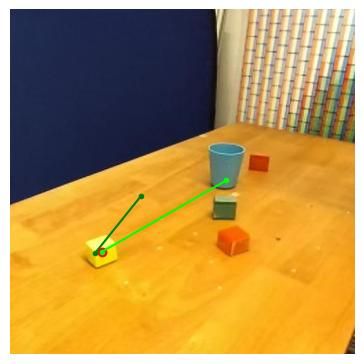
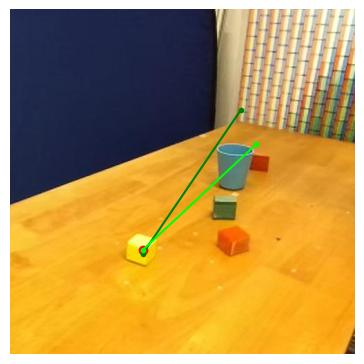
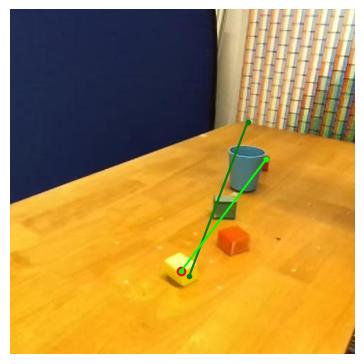
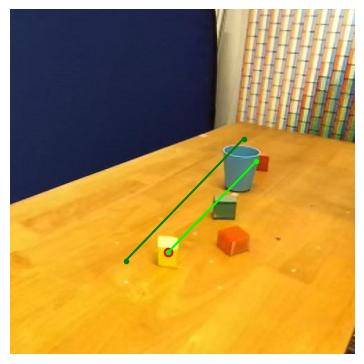
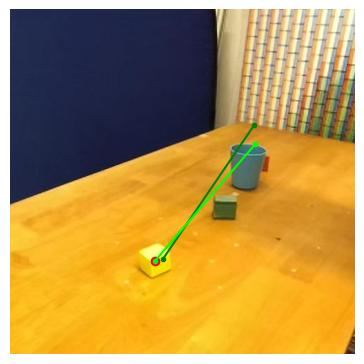
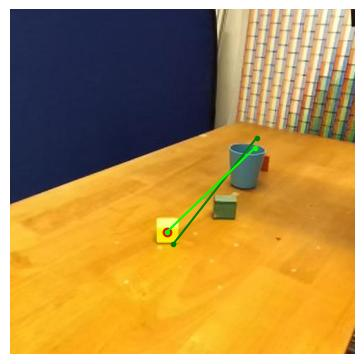
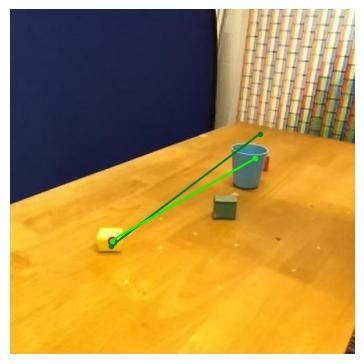
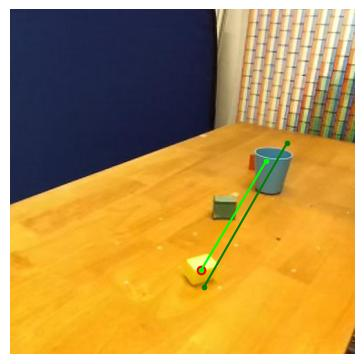
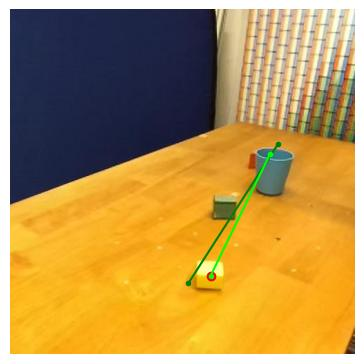
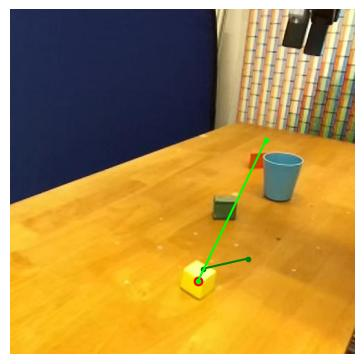
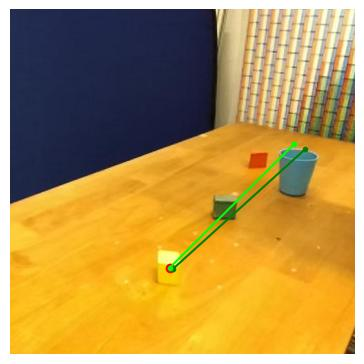
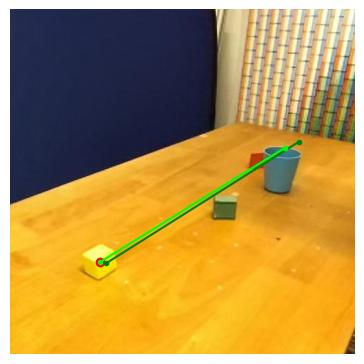
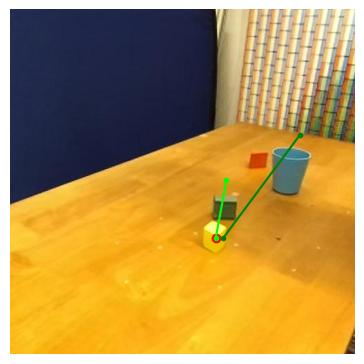
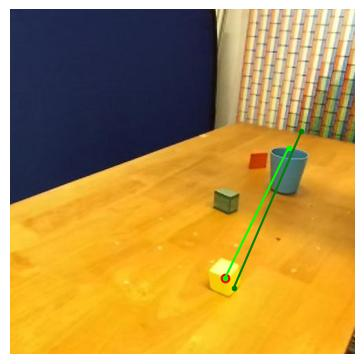
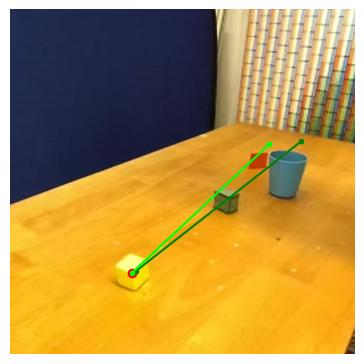
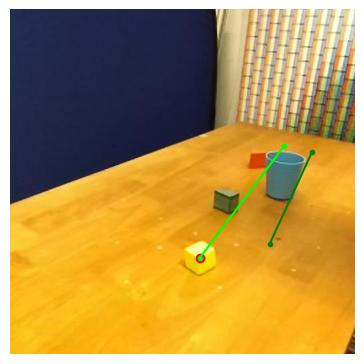
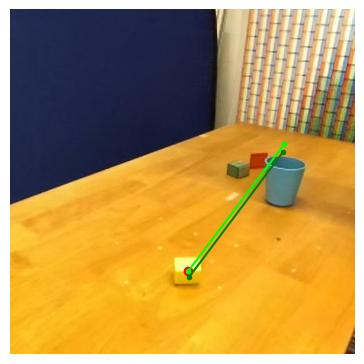
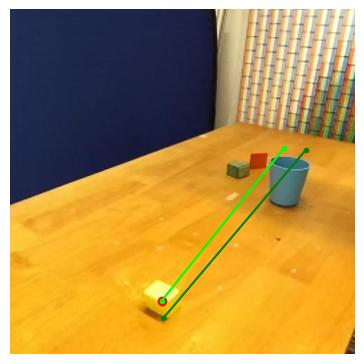
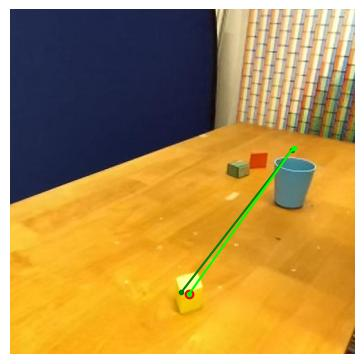
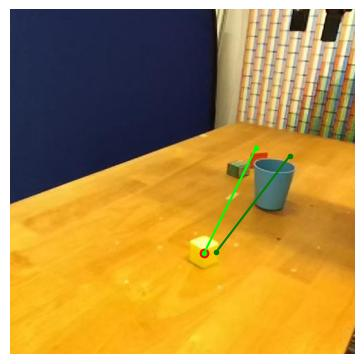
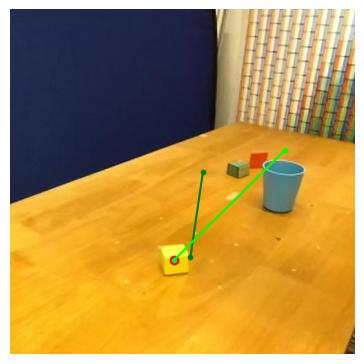
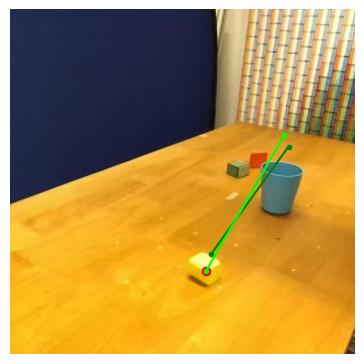
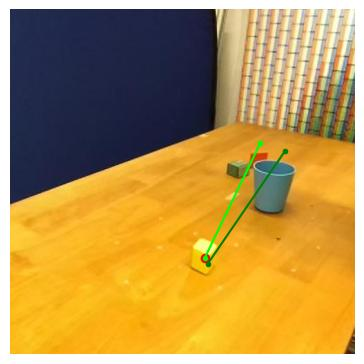
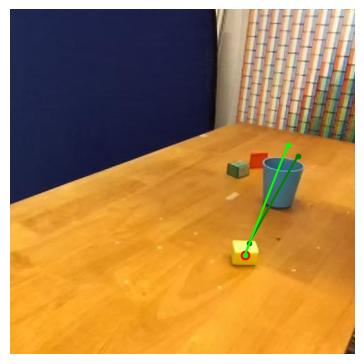
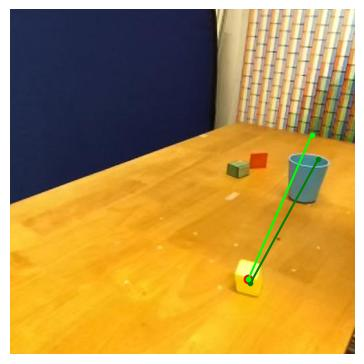
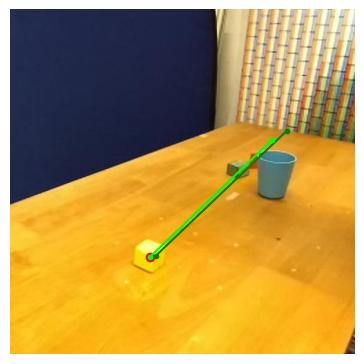
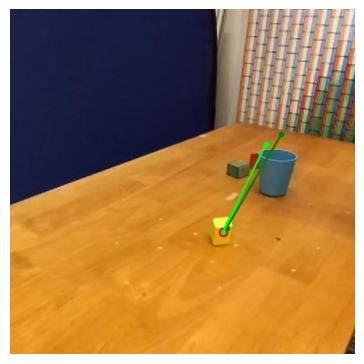
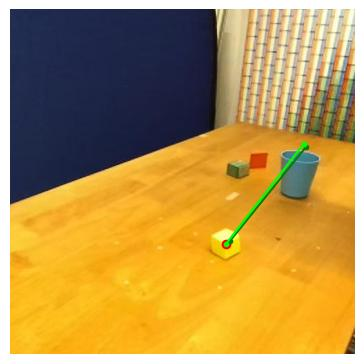
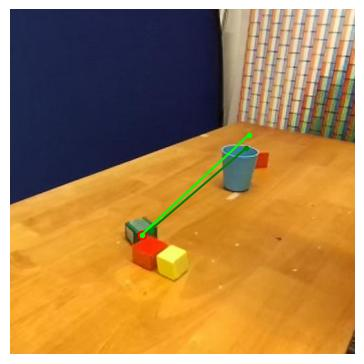

In [9]:
from tqdm.notebook import tqdm
from utils_vis import render_example
from utils_trajectory import DummyCamera
from math import ceil
from pathlib import Path

import re
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

crop_size = 500

eval_batch_size = 1
#if return_depth:
#    eval_batch_size = 1

#def augment_sample(sample):
#    sample[1]["prefix"] = sample[1]["prefix"].replace("blue cup", "crockery").replace("cup","crockery")
    
#test_samples = eval_batch_size*3
test_samples = len(test_dataset)

#sample_list = [0] # 0v, 4x, 6v, 7v, 8x, 12v, 19x
sample_list = list(range(test_samples))

pred_list = []
html_imgs = ""
for start_idx in tqdm(sample_list): #tqdm(range(0, test_samples, eval_batch_size), total=ceil(test_samples / eval_batch_size)):
    batch = [test_dataset[i] for i in range(start_idx, min(start_idx + eval_batch_size, test_samples))]
    #for e in batch:
    #    augment_sample(e)
    inputs = collate_fn(batch) # inspect with inputs.keys()
    prefix_length = inputs["input_ids"].shape[-1]    

    with torch.inference_mode():
        generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False, 
                                    return_dict_in_generate=True, output_scores=True, 
                                    #logits_processor=[MyProcessor()], 
                                    #num_beams=3, 
                                    #num_return_sequences=3,
                                    early_stopping=True
                                    )
        # inspect with generation.keys()
        decoded = [processor.decode(x, skip_special_tokens=True) for x in generation.sequences[:, prefix_length:]]
    pred_list.extend(decoded)

    episode_indices = range(start_idx, min(start_idx + eval_batch_size, test_samples))
    for batch_entry, decoded_str, episode_i in zip(batch, decoded, episode_indices):
        if return_depth:
            (depth, image), sample = batch_entry
        else:
            image, sample = batch_entry

        # === save model output
        # === tokens vector = language tokens, ... 1024 x loc, 128 x seg
        scores = torch.stack(generation.scores).cpu().numpy() # (prediction_steps, 1, total_tokens)
        _, _, n_tokens = scores.shape
        loc_first = n_tokens - 1024 - 128 - 64
        loc_last = n_tokens - 128 - 64
        scores = scores[:, :, loc_first:loc_last]
        
        #with open(save_folder + f"tokens_{episode_i:04d}.npy", "wb") as f:
        with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "wb") as f:
            np.save(f, decoded_str)
            #np.save(f, scores)
            np.save(f, generation.sequences.cpu().numpy())
            #np.save(f, generation.sequences_scores.cpu().numpy())
        
        html_img = render_example(image, text=sample["prefix"], label=sample["suffix"], prediction=decoded_str, camera=sample["camera"])
        html_imgs += html_img

plot_images = True
if plot_images:
    from IPython.display import display, HTML
    display(HTML(html_imgs))

In [10]:
print(type(generation.scores))
print(generation.keys())

<class 'tuple'>
odict_keys(['sequences', 'scores'])


In [11]:
generation.sequences.shape

torch.Size([1, 284])

In [12]:
generation.sequences_scores.shape

AttributeError: 'GenerateDecoderOnlyOutput' object has no attribute 'sequences_scores'

[-5.577599 -6.483849 -5.140099]


Text(0.5, 0, 'x')

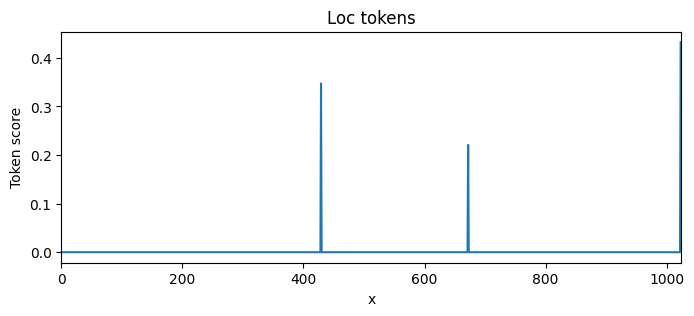

In [104]:
token_pos = 6 # 0 - start y, 1 - start x, 6 - end y, 7 - end x

probas = scores[token_pos, 0]
print(probas[~np.isinf(probas)])

#probas[np.isinf(probas)] = 0

# === softmax
temp = 2
probas = np.exp(probas / temp)
probas = probas / (np.sum(probas) + 1e-6)

fig, ax = plt.subplots(figsize=(8, 3))
#ax.scatter(tokens, probas, color='skyblue', alpha=0.3)
ax.plot(np.arange(0, 1024), probas)
ax.set_xlim(0, 1024)
ax.set_ylabel("Token score")
ax.set_title("Loc tokens")
ax.set_xlabel("x")

In [78]:
print(len(generation.scores))
print(generation.beam_indices)

12
tensor([[ 0,  0,  0,  1,  2,  2,  2,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
         -1, -1, -1, -1, 

## Generate for all crop sizes

In [16]:
import math
from data_loader_jsonl import JSONLDataset, ValidDataset
from data_augmentations import CropStart, CropMiddle, CropCenter

def save_model_output(generation, filename, save_beams=False):
    """
    tokens vector = language tokens, 1024 x loc, 128 x seg, 64 x special
    """
    scores = torch.stack(generation.scores).cpu().numpy() # (prediction_steps, 1, n_tokens)
    _, _, n_tokens = scores.shape
    loc_first = n_tokens - 1024 - 128 - 64
    loc_last = n_tokens - 128 - 64
    scores = scores[:, :, loc_first:loc_last]
    
    with open(filename, "wb") as f:
        np.save(f, generation.sequences.cpu().numpy())
        np.save(f, scores)
        if save_beams:
            np.save(f, generation.sequences_scores.cpu().numpy())

for crop_size in range(500, 1300, 200):
    test_dataset = JSONLDataset(
        jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
        image_directory_path=f"{dataset_location}/dataset",
        clean_prompt=True,
        augment_crop=CropCenter(crop_size=crop_size, valid=False),
        return_depth=return_depth
    )
    
    print("dataset len", len(test_dataset))

    eval_batch_size = 1
    test_samples = len(test_dataset)
    sample_list = list(range(test_samples))

    pred_list = []
    html_imgs = ""
    for start_idx in tqdm(range(0, test_samples, eval_batch_size), total=math.ceil(test_samples / eval_batch_size)):
        batch = [test_dataset[i] for i in range(start_idx, min(start_idx + eval_batch_size, test_samples))]
        #for e in batch:
        #    augment_sample(e)
        inputs = collate_fn(batch) # inspect with inputs.keys()
        prefix_length = inputs["input_ids"].shape[-1]    
    
        with torch.inference_mode():
            generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False, 
                                        return_dict_in_generate=True, output_scores=True)
            # inspect with generation.keys()
            decoded = [processor.decode(x, skip_special_tokens=True) for x in generation.sequences[:, prefix_length:]]
        pred_list.extend(decoded)
    
        episode_indices = range(start_idx, min(start_idx + eval_batch_size, test_samples))
        for batch_entry, decoded_str, episode_i in zip(batch, decoded, episode_indices):
            image, sample = batch_entry

            # === save model output
            file = save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy"
            save_model_output(generation, file)

dataset len 160


  0%|          | 0/160 [00:00<?, ?it/s]

dataset len 160


  0%|          | 0/160 [00:00<?, ?it/s]

dataset len 160


  0%|          | 0/160 [00:00<?, ?it/s]

dataset len 160


  0%|          | 0/160 [00:00<?, ?it/s]

In [17]:
with open(save_folder + "tokens_0000_0500.npy", "rb") as f:
    decoded_str = np.load(f)
    scores = np.load(f)
    sequence_scores = np.load(f)
print(decoded_str)
print(scores.shape)
print(sequence_scores.shape)

EOFError: No data left in file

Text(0.5, 0, 'x')

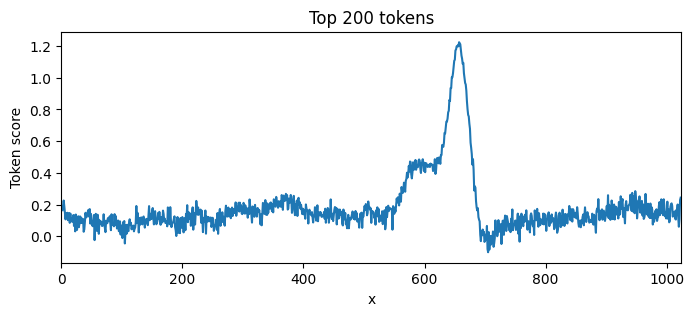

In [58]:
token_pos = 7 # 0 - start y, 1 - start x, 6 - end y, 7 - end x

probas = scores[token_pos, 0]

# === only loc tokens
# === tokens vector = language tokens, ... 1024 x loc, 128 x seg
# all_tokens = generation.scores[token_pos].cpu().numpy() # (1, n_tokens)
# _, n_tokens = all_tokens.shape
# loc_first = n_tokens - 1024 - 128 - 64
# loc_last = n_tokens - 128 - 64
# probas = all_tokens[0, loc_first:loc_last]
# tokens = np.arange(0, 1024)
# imginfo(probas)
# print(loc_first, loc_last)

# === softmax
# temp = 50
# probas = np.exp(probas / temp)
# probas = probas / (np.sum(probas) + 1e-3)

low = np.quantile(probas, 0.02)
high = np.quantile(probas, 0.98)
probas = (probas - low) / (high - low + 1e-3) # scale to [0, 1], with outliers
color = np.clip(probas, 0, 1)


# === top k
# k = 200
# res = torch.topk(generation.scores[token_pos], k)
# probas = res.values.cpu().numpy()[0]
# tokens = res.indices
# decoded = [processor.decode(x, skip_special_tokens=True) for x in tokens] # (1, tokens)
# loc_strings = [int(x) for x in re.findall(r"<(?:loc|seg)(-?\d+)>", decoded[0])]

fig, ax = plt.subplots(figsize=(8, 3))
#ax.scatter(tokens, probas, color='skyblue', alpha=0.3)
ax.plot(np.arange(0, 1024), probas)
ax.set_xlim(0, 1024)
ax.set_ylabel("Token score")
ax.set_title("Top 200 tokens")
ax.set_xlabel("x")

## Evaluate precomputed results

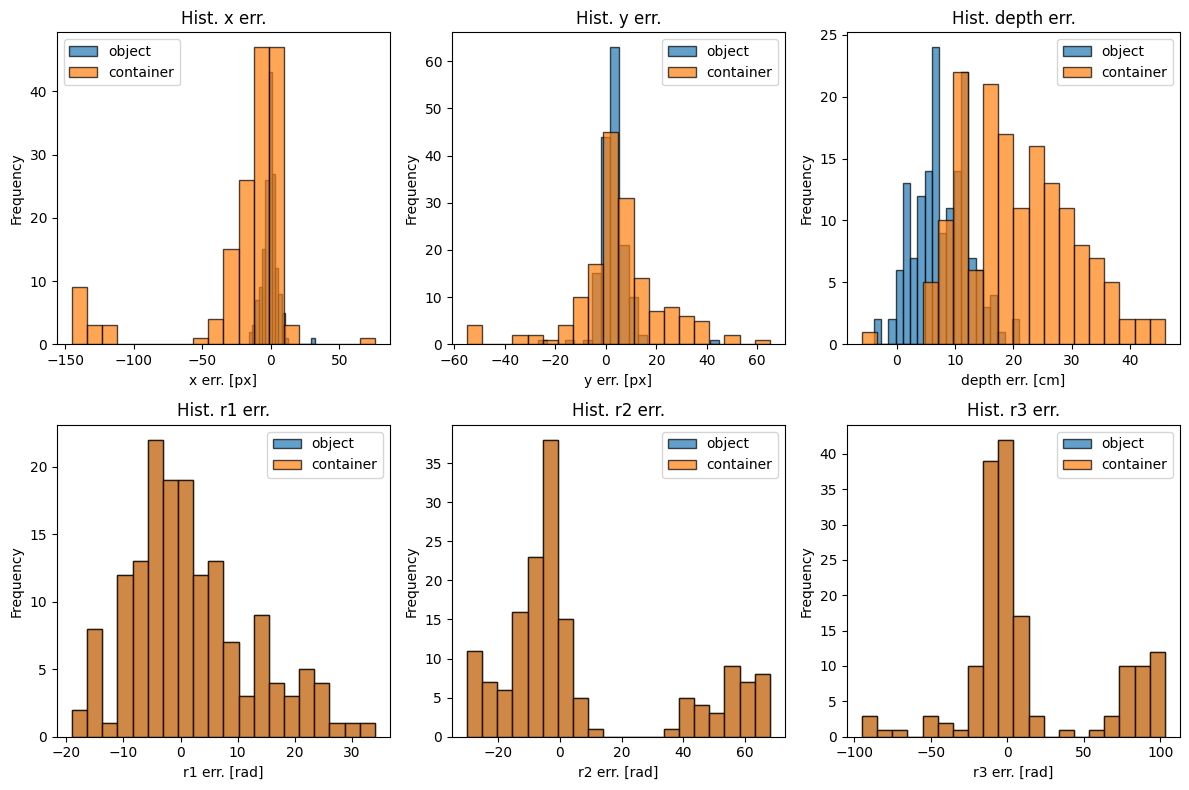

Valid Samples: 159 L1: 15.722746331236896

L1_depth 7.754716981132075


In [13]:
import re
import numpy as np
import matplotlib.pyplot as plt

# Compute results from pred_list = [decoded str i, ...]

crop_size = 500

# Load dataset again
test_dataset = JSONLDataset(
    jsonl_file_path=f"{dataset_location}/_annotations.valid.jsonl",
    image_directory_path=f"{dataset_location}/dataset",
    clean_prompt=True,
    #augment_crop=CropMiddle(crop_size=crop_size, object_size=20, valid=True),
    augment_crop=CropCenter(crop_size=crop_size, valid=False),
    return_depth=return_depth
)

# Define episodes to load results
test_samples = len(test_dataset)
sample_list = list(range(test_samples))

pred_list = []
for episode_i in sample_list:
    with open(save_folder + f"tokens_{episode_i:04d}_{crop_size:04d}.npy", "rb") as f:
    #with open(save_folder + f"tokens_{episode_i:04d}.npy", "rb") as f:
        decoded_str = str(np.load(f))
        scores =  np.load(f)
    pred_list.append(decoded_str)

# Max part

results = []
for i, pred in enumerate(pred_list):
    suffix = test_dataset[i][1]["suffix"]
    suffix_p = [int(x) for x in re.findall(r"<(?:loc|seg)(\d+)>", suffix)]
    decode_p = [int(x) for x in re.findall(r"<(?:loc|seg)(\d+)>", pred)]
    if len(suffix_p) != 12 or len(decode_p) != 12:
        continue
    pred_diff = np.array(suffix_p) - np.array(decode_p)
    results.append(pred_diff)
results = np.array(results)

results[:, 0:2] = results[:, 0:2]/1024*224 
results[:, 6:8] = results[:, 6:8]/1024*224 


keypoint = ["object","container"]
action_labels = ["x","y","depth","r1","r2","r3"]*2
units         = ["px","px","cm","rad","rad","rad"]*2
plot_hist=True
if plot_hist:
    fig, axes = plt.subplots(2, 3, figsize=(12, 12*2/3))  # 3 rows x 4 columns of histograms
    axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
    for i in range(2):
        for j in range(6):
            axes[j].hist(results[:, i*6+j], bins=20, alpha=0.7,  edgecolor='black', label=keypoint[i])
            axes[j].set_title(f'Hist. {action_labels[j]} err.')
            axes[j].set_xlabel(f"{action_labels[j]} err. [{units[j]}]")
            axes[j].set_ylabel('Frequency')
            axes[j].legend()
    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()

print("Valid Samples:", len(results), "L1:",np.mean(np.abs(results)))
print()
print("L1_depth", np.mean(np.abs(results[:,2])))

In [14]:
# RGB Networks
# Valid Samples: 157 L1: 35.67 (no-agug)
# Valid Samples: 160 L1: 34.35 (prompt cleaning) 33.89
# Valid Samples: 160 L1: 34.62 (prompt cleaning + simplify text)  -- similar

# Valid Samples: 160 L1: 24.96 (rgb20 = augmentation + random background (CVPR09-dataset))
# Valid Samples: 160 L1: 26.61 (rgb20 + simplify text) -- worse
# Valid Samples: 150 L1: 40.55 (augmentation + DROID background)  -- way worse


# With depth (only 31 samples for real data)
# Valid Samples: 31 L1: 29.24 (no text aug, NaN-to-Max eval)
# Valid Samples: 31 L1: 28.58  L1_depth 6.29375 (no text aug, Nan-to-Min eval)  
# Valid Samples: 160 L1: 27.93 6.29375 (no text aug, all-zero)

# Valid, no crop: 160 L1 17.21, depth 8.05
# Valid, crop 800: 158 L1: 13.13, depth 6.7
# Valid, crop 500: 159 L1: 14.41, depth 5.0

# Beam search
# Valid, no crop: 160 L1 17.20, depth 7.97
# Valid, crop 500: 159 L1: 14.16, depth 5.0

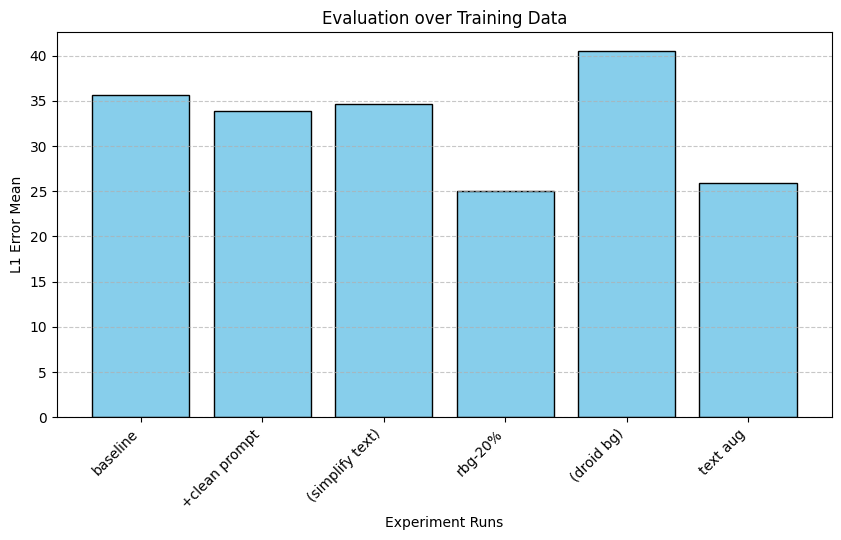

In [10]:
eval_on_blocks = {"baseline":35.67, "+clean prompt": 33.89, "(simplify text)":34.62,
                  "rbg-20%": 24.96, "(droid bg)": 40.55, "text aug": 25.93}


# Extract labels and values
labels, values = zip(*eval_on_blocks.items())

# Plot
plt.figure(figsize=(10, 5))
plt.bar(labels, values, color='skyblue', edgecolor='black')

# Formatting
plt.ylabel("L1 Error Mean")
plt.title("Evaluation over Training Data")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.xlabel("Experiment Runs")
plt.grid(axis="y", linestyle="--", alpha=0.7)  # Add grid lines for readability

# Show plot
plt.show()

In [8]:
# from matplotlib import pyplot as plt
# import re
# import numpy as np
# results = []
# suffix_nums = []
# predi_nums = []
# for i in range(test_samples):
#     suffix = test_dataset[i][1]["suffix"]
#     prefix = test_dataset[i][1]["prefix"]
#     decoded = decode_dataset[i]
#     suffix_p = [int(x) for x in re.findall(r"<(?:loc|seg)(\d+)>", suffix)]
#     try:
#         decode_p = [int(x) for x in re.findall(r"<(?:loc|seg)(\d+)>", decoded)]
#     except ValueError:
#         continue
#     if len(decode_p) != 12:
#         continue
#     pred_diff = np.array(suffix_p) - np.array(decode_p)
#     results.append(pred_diff)
#     suffix_nums.append(suffix_p)
#     predi_nums.append(decode_p)

# results = np.array(results)
# #suffix_nums = np.array(suffix_nums) / 1024 * 448
# #predi_nums = np.array(predi_nums) / 1024 * 448

# print(results)
# print(np.abs(results).mean(axis=0).round())

# plot_histogram = True
# if plot_histogram:
#     fig, axes = plt.subplots(4, 3, figsize=(10, 12))  # 3 rows x 4 columns of histograms
#     axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
#     for i in range(12):
#         axes[i].hist(results[:, i], bins=20, alpha=0.7, color='blue', edgecolor='black')
#         axes[i].set_title(f'Histogram for Column {i + 1}')
#         axes[i].set_xlabel('Value')
#         axes[i].set_ylabel('Frequency')

#     plt.tight_layout()  # Adjust layout for better spacing
#     plt.show()

# Simulation Eval

In [9]:
# import numpy as np
# class ModelWrapper:
#     def __init__(self, transformers_model=model):
#         self.model = transformers_model
    
#     def make_predictions(self, image, prefix):
#         prefix = "<image>" + prefix
#         image = Image.fromarray(image)
#         inputs = processor(text=prefix,
#                            images=image,
#                            return_tensors="pt").to(TORCH_DTYPE).to(DEVICE)
#         prefix_length = inputs["input_ids"].shape[-1]
#         with torch.inference_mode():
#             generation = model.generate(**inputs, max_new_tokens=12, do_sample=False, use_cache=False)
#             generation = generation[0][prefix_length:]
#             decoded = processor.decode(generation, skip_special_tokens=True)
#         return None, None, None, decoded
# model_wrapped = ModelWrapper(model)

# i = 0
# image, label = test_dataset[i]
# print(image)
# print(label["prefix"])
# res = model_wrapped.make_predictions(np.asarray(image), label["prefix"])
# print(res)


In [10]:
# %reload_ext autoreload
# %autoreload 2
# import json
# from PIL import Image
# from mani_skill.examples.run_env import Args, iterate_env, save_dataset

        
# parsed_args = Args()
# parsed_args.env_id = "ClevrMove-v1"
# parsed_args.render_mode = "rgb_array"
# parsed_args.control_mode = "pd_joint_pos"

# env_iter = iterate_env(parsed_args, vis=False, model=model_wrapped)

In [11]:
# for i in range(25):
#     next(env_iter)

In [12]:
# import torch
# model_path = model_location / "clevr-act-6-var-cam2_hf_af_lr3e5"
# training_args_good = torch.load(model_path / "checkpoint-4687" / "training_args.bin", weights_only=False)

# model_path = model_location / "clevr-act-7-depth_test_h5"
# training_args_bad = torch.load(model_path / "checkpoint-start" / "training_args.bin", weights_only=False)

# def compare(a, b, depth=0):
#     for attr in dir(a):
#         if attr.startswith("__"):
#             continue
#         a_good = a.__getattribute__(attr)
#         a_bad = a.__getattribute__(attr)

#         if a_good == a_bad:
#             continue
#         elif isisntance(a_good, (str, int, list, tuple)):
#             print(attr, "good=",a_good, "bad=",a_bad)
#         elif depth < 2:
#             print(type(a_good))
#             compare(a_good, a_bad, depth+1)
        
        
            
# compare(training_args_good, training_args_bad)